# Modelo LSTM — Predicción de consumo eléctrico

Este notebook construye, entrena y evalúa una red LSTM para predecir el consumo eléctrico real en España.

**Objetivo:** dado un historial de 24 horas, predecir el consumo de la hora siguiente (`total load actual`).

## 1. Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import joblib
import os

# Semilla para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.21.0


## 2. Carga y preprocesamiento de datos

In [2]:
# Carga
energy = pd.read_csv('data/energy_dataset.csv')
weather = pd.read_csv('data/weather_features.csv')

# Parseo de fechas con UTC
energy['time'] = pd.to_datetime(energy['time'], utc=True)
weather['dt_iso'] = pd.to_datetime(weather['dt_iso'], utc=True)

print(f'Energy: {energy.shape}')
print(f'Weather: {weather.shape}')

Energy: (35064, 29)
Weather: (178396, 17)


In [3]:
# Eliminamos columnas completamente vacías
cols_drop = ['generation hydro pumped storage aggregated', 'forecast wind offshore eday ahead']
energy.drop(columns=cols_drop, inplace=True)

# Eliminamos filas donde el objetivo es nulo
energy.dropna(subset=['total load actual'], inplace=True)

# Interpolamos el resto de nulos (son menos del 0.1%)
energy.interpolate(method='linear', inplace=True)

print(f'Nulos restantes: {energy.isnull().sum().sum()}')

Nulos restantes: 0


In [4]:
# Agregamos el clima: media horaria de las 5 ciudades
weather_agg = weather.groupby('dt_iso').agg({
    'temp': 'mean',
    'humidity': 'mean',
    'wind_speed': 'mean',
    'clouds_all': 'mean'
}).reset_index()
weather_agg.columns = ['time', 'temp', 'humidity', 'wind_speed', 'clouds']

# Merge
df = pd.merge(energy, weather_agg, on='time', how='inner')
df.sort_values('time', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Dataset combinado: {df.shape}')

Dataset combinado: (35028, 31)


In [5]:
# Features temporales cíclicas
# Usamos seno/coseno para que la LSTM entienda que hora 23 y hora 0 son consecutivas
df['hour_sin'] = np.sin(2 * np.pi * df['time'].dt.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['time'].dt.hour / 24)
df['dow_sin'] = np.sin(2 * np.pi * df['time'].dt.dayofweek / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['time'].dt.dayofweek / 7)
df['month_sin'] = np.sin(2 * np.pi * df['time'].dt.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df['time'].dt.month / 12)

print('Features temporales añadidas.')

Features temporales añadidas.


In [6]:
# Selección de features para el modelo
FEATURES = [
    'total load actual',
    'generation nuclear',
    'generation wind onshore',
    'generation solar',
    'generation fossil gas',
    'temp', 'humidity', 'wind_speed', 'clouds',
    'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos'
]
TARGET = 'total load actual'

data = df[FEATURES].values
print(f'Shape del dataset final: {data.shape}')
print(f'Features: {FEATURES}')

Shape del dataset final: (35028, 15)
Features: ['total load actual', 'generation nuclear', 'generation wind onshore', 'generation solar', 'generation fossil gas', 'temp', 'humidity', 'wind_speed', 'clouds', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']


## 3. Normalización y split train/val/test

In [7]:
# Split temporal: 70% train, 15% val, 15% test
n = len(data)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_data = data[:train_end]
val_data   = data[train_end:val_end]
test_data  = data[val_end:]

print(f'Train: {len(train_data)} muestras')
print(f'Val:   {len(val_data)} muestras')
print(f'Test:  {len(test_data)} muestras')

Train: 24519 muestras
Val:   5254 muestras
Test:  5255 muestras


In [8]:
# Normalizamos con MinMaxScaler
# IMPORTANTE: el scaler se ajusta SOLO con train para evitar data leakage
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled   = scaler.transform(val_data)
test_scaled  = scaler.transform(test_data)

# Guardamos el scaler para usarlo en Streamlit
os.makedirs('model', exist_ok=True)
joblib.dump(scaler, 'model/scaler.pkl')
print('Scaler guardado en model/scaler.pkl')

Scaler guardado en model/scaler.pkl


## 4. Construcción de ventanas deslizantes

La LSTM necesita secuencias como entrada. Usamos una ventana de **24 horas** para predecir la hora siguiente.

```
[h0, h1, ..., h23] → predice h24
[h1, h2, ..., h24] → predice h25
...
```

In [9]:
WINDOW = 24  # horas de historial
TARGET_IDX = FEATURES.index(TARGET)  # índice de la columna objetivo

def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i - window:i])          # ventana de 24 pasos
        y.append(data[i, TARGET_IDX])          # valor siguiente del objetivo
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, WINDOW)
X_val,   y_val   = create_sequences(val_scaled,   WINDOW)
X_test,  y_test  = create_sequences(test_scaled,  WINDOW)

print(f'X_train shape: {X_train.shape}  → (muestras, timesteps, features)')
print(f'X_val shape:   {X_val.shape}')
print(f'X_test shape:  {X_test.shape}')

X_train shape: (24495, 24, 15)  → (muestras, timesteps, features)
X_val shape:   (5230, 24, 15)
X_test shape:  (5231, 24, 15)


## 5. Arquitectura del modelo LSTM

In [10]:
n_features = X_train.shape[2]

model = Sequential([
    # Primera capa LSTM: aprende patrones temporales complejos
    LSTM(128, return_sequences=True, input_shape=(WINDOW, n_features)),
    Dropout(0.2),  # Regularización para evitar overfitting

    # Segunda capa LSTM: refina las representaciones aprendidas
    LSTM(64, return_sequences=False),
    Dropout(0.2),

    # Capa densa intermedia
    Dense(32, activation='relu'),

    # Salida: un único valor (consumo predicho)
    Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

c:\Users\migue\Desktop\Evaluacion 1\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,249 (489.25 KB)

 Trainable params: 125,249 (489.25 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Entrenamiento

In [11]:
# Early stopping: para el entrenamiento si val_loss no mejora en 10 épocas
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Guardamos el mejor modelo automáticamente
checkpoint = ModelCheckpoint(
    'model/lstm_best.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=0
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - loss: 0.0152 - mae: 0.0922 - val_loss: 0.0049 - val_mae: 0.0529
Epoch 2/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0053 - mae: 0.0561 - val_loss: 0.0034 - val_mae: 0.0450
Epoch 3/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 0.0038 - mae: 0.0476 - val_loss: 0.0026 - val_mae: 0.0388
Epoch 4/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 0.0030 - mae: 0.0422 - val_loss: 0.0017 - val_mae: 0.0312
Epoch 5/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 0.0023 - mae: 0.0367 - val_loss: 0.0016 - val_mae: 0.0297
Epoch 6/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 0.0019 - mae: 0.0328 - val_loss: 0.0011 - val_mae: 0.0244
Epoch 7/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 0.0016 - mae: 0.0304 - val_loss: 0.0010 - val_mae: 0.0227
Epoch 8/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0015 - mae: 0.0286 - val_loss: 8.7682e-04 - val_mae: 0.0211
Epoch 9/50
383/383 ━━━━━━━━━━━━━━━━━━━

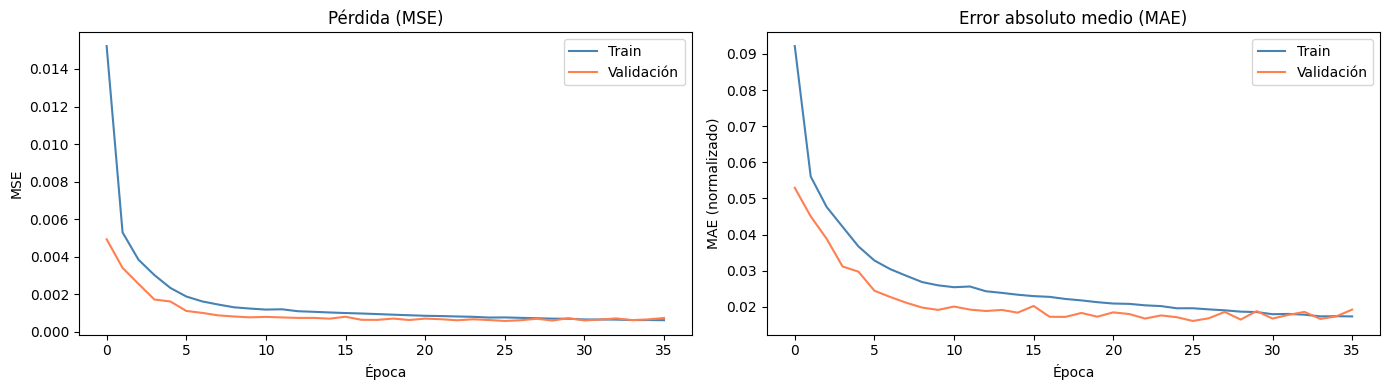

In [12]:
# Curvas de pérdida
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'], label='Train', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Validación', color='coral')
axes[0].set_title('Pérdida (MSE)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train', color='steelblue')
axes[1].plot(history.history['val_mae'], label='Validación', color='coral')
axes[1].set_title('Error absoluto medio (MAE)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAE (normalizado)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Evaluación en test

In [13]:
# Predicciones sobre test
y_pred_scaled = model.predict(X_test)

# Desnormalizamos para obtener valores en MW
# Creamos arrays del mismo shape que el scaler espera
def inverse_target(scaled_values, scaler, target_idx, n_features):
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, target_idx] = scaled_values.flatten()
    return scaler.inverse_transform(dummy)[:, target_idx]

y_pred_mw = inverse_target(y_pred_scaled, scaler, TARGET_IDX, n_features)
y_test_mw = inverse_target(y_test, scaler, TARGET_IDX, n_features)

print(f'Predicciones generadas: {len(y_pred_mw)}')

164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Predicciones generadas: 5231


In [14]:
# Métricas
mae  = mean_absolute_error(y_test_mw, y_pred_mw)
rmse = np.sqrt(mean_squared_error(y_test_mw, y_pred_mw))
r2   = r2_score(y_test_mw, y_pred_mw)

# MAE del TSO en el mismo periodo de test
test_start_idx = val_end + WINDOW
tso_actual   = df['total load actual'].values[test_start_idx:]
tso_forecast = df['total load forecast'].values[test_start_idx:]
# Alineamos longitudes
min_len = min(len(tso_actual), len(y_test_mw))
mae_tso = mean_absolute_error(tso_actual[:min_len], tso_forecast[:min_len])

print('=' * 40)
print(f'  MAE  LSTM : {mae:.2f} MW')
print(f'  RMSE LSTM : {rmse:.2f} MW')
print(f'  R²   LSTM : {r2:.4f}')
print('-' * 40)
print(f'  MAE  TSO  : {mae_tso:.2f} MW  (baseline)')
print('=' * 40)

  MAE  LSTM : 370.08 MW
  RMSE LSTM : 520.19 MW
  R²   LSTM : 0.9871
----------------------------------------
  MAE  TSO  : 253.88 MW  (baseline)


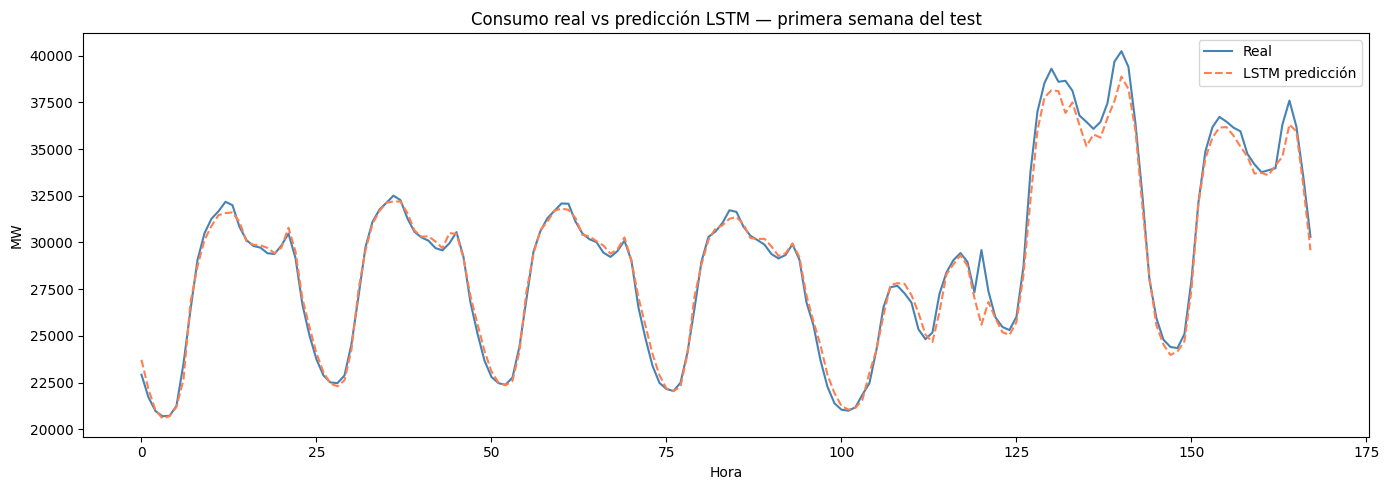

In [15]:
# Predicción vs real — primera semana del test
fig, ax = plt.subplots(figsize=(14, 5))
horas = 24 * 7  # una semana
ax.plot(y_test_mw[:horas], label='Real', color='steelblue', linewidth=1.5)
ax.plot(y_pred_mw[:horas], label='LSTM predicción', color='coral', linewidth=1.5, linestyle='--')
ax.set_title('Consumo real vs predicción LSTM — primera semana del test')
ax.set_xlabel('Hora')
ax.set_ylabel('MW')
ax.legend()
plt.tight_layout()
plt.show()

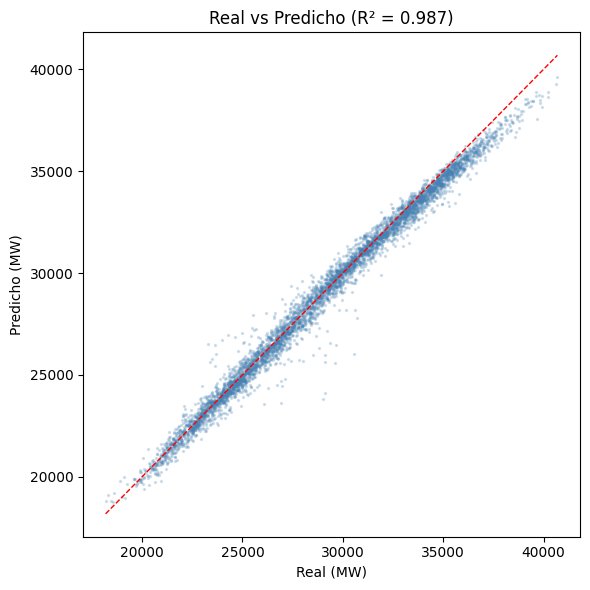

In [16]:
# Scatter: real vs predicho
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_mw, y_pred_mw, alpha=0.2, s=2, color='steelblue')
lims = [min(y_test_mw.min(), y_pred_mw.min()), max(y_test_mw.max(), y_pred_mw.max())]
ax.plot(lims, lims, 'r--', linewidth=1)
ax.set_title(f'Real vs Predicho (R² = {r2:.3f})')
ax.set_xlabel('Real (MW)')
ax.set_ylabel('Predicho (MW)')
plt.tight_layout()
plt.show()

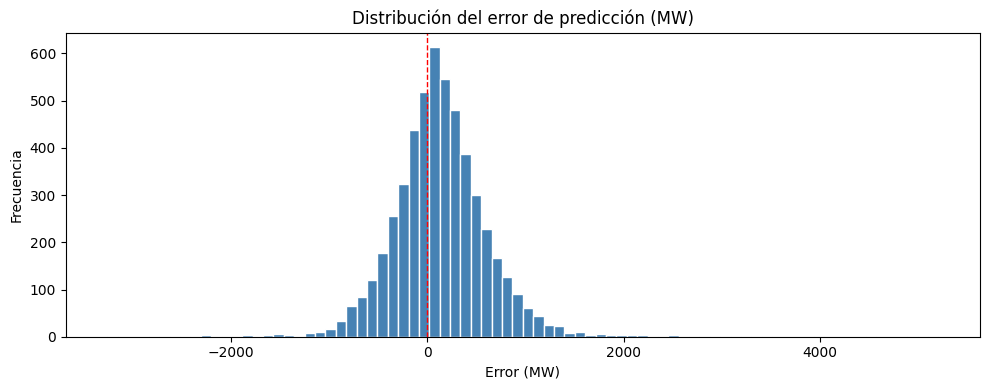

In [17]:
# Distribución del error de predicción
errors = y_test_mw - y_pred_mw

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(errors, bins=80, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Distribución del error de predicción (MW)')
ax.set_xlabel('Error (MW)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

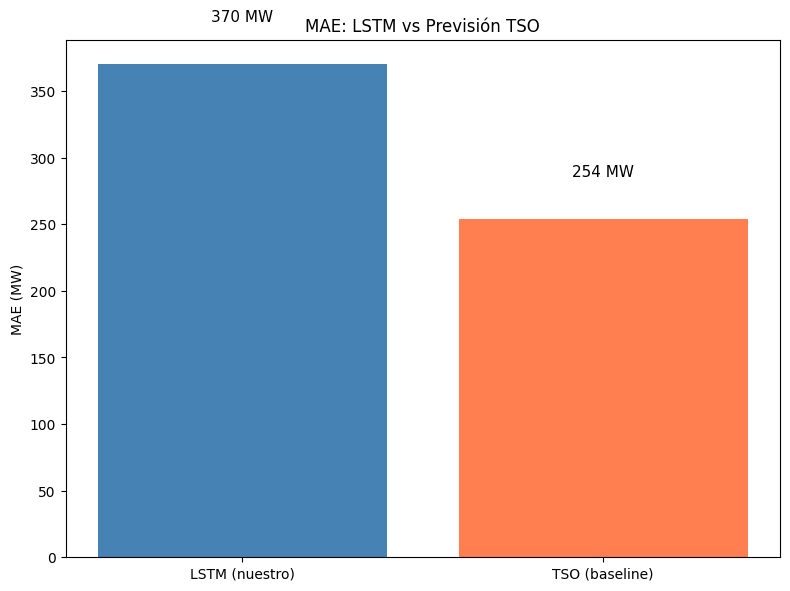

In [18]:
# Comparativa LSTM vs TSO en barra
fig, ax = plt.subplots(figsize=(8, 6))
modelos = ['LSTM (nuestro)', 'TSO (baseline)']
maes = [mae, mae_tso]
colors = ['steelblue', 'coral']
bars = ax.bar(modelos, maes, color=colors)
for bar, val in zip(bars, maes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:.0f} MW', ha='center', va='bottom', fontsize=11)
ax.set_title('MAE: LSTM vs Previsión TSO')
ax.set_ylabel('MAE (MW)')
plt.tight_layout()
plt.show()

## 8. Hyperparameter Tuning con Keras Tuner

Hasta ahora hemos usado una arquitectura razonada pero fija. En esta sección buscamos sistemáticamente la mejor combinación de hiperparámetros usando **RandomSearch**.

Hiperparámetros explorados:
- Neuronas capa LSTM 1: 64, 128, 256
- Neuronas capa LSTM 2: 32, 64, 128
- Dropout: 0.1, 0.2, 0.3
- Learning rate: 0.001, 0.0005, 0.0001

In [19]:
import subprocess
subprocess.run(['pip', 'install', 'keras-tuner', '-q'], check=True)
import keras_tuner as kt
print(f'Keras Tuner version: {kt.__version__}')

Keras Tuner version: 1.4.8


In [20]:
def build_model(hp):
    units_1 = hp.Choice('units_1', values=[64, 128, 256])
    units_2 = hp.Choice('units_2', values=[32, 64, 128])
    dropout = hp.Choice('dropout', values=[0.1, 0.2, 0.3])
    lr      = hp.Choice('learning_rate', values=[0.001, 0.0005, 0.0001])

    model_hp = Sequential([
        LSTM(units_1, return_sequences=True, input_shape=(WINDOW, n_features)),
        Dropout(dropout),
        LSTM(units_2, return_sequences=False),
        Dropout(dropout),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model_hp.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae']
    )
    return model_hp

In [21]:
import sys
print(sys.executable)

c:\Users\migue\Desktop\Evaluacion 1\.venv\Scripts\python.exe


In [22]:
import subprocess
subprocess.run(['pip', 'install', 'tensorboard', 'keras-tuner', '-q'], check=True)

tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=15,
    seed=42,
    directory=os.path.join(os.getcwd(), 'kt_results'),
    project_name='lstm_energy'
)

early_stop_tuner = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop_tuner],
    verbose=1
)

Trial 15 Complete [00h 02m 56s]
val_loss: 0.0006518314476124942

Best val_loss So Far: 0.0006135745206847787
Total elapsed time: 00h 47m 14s


In [23]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print('Mejores hiperparámetros:')
print(f'  LSTM capa 1:   {best_hp.get("units_1")} neuronas')
print(f'  LSTM capa 2:   {best_hp.get("units_2")} neuronas')
print(f'  Dropout:       {best_hp.get("dropout")}')
print(f'  Learning rate: {best_hp.get("learning_rate")}')

Mejores hiperparámetros:
  LSTM capa 1:   128 neuronas
  LSTM capa 2:   128 neuronas
  Dropout:       0.2
  Learning rate: 0.001


In [24]:
best_model = tuner.hypermodel.build(best_hp)

history_tuned = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ModelCheckpoint('model/lstm_tuned.keras', monitor='val_loss', save_best_only=True)
    ],
    verbose=1
)

Epoch 1/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - loss: 0.0112 - mae: 0.0792 - val_loss: 0.0046 - val_mae: 0.0528
Epoch 2/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.0044 - mae: 0.0510 - val_loss: 0.0032 - val_mae: 0.0432
Epoch 3/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.0033 - mae: 0.0439 - val_loss: 0.0022 - val_mae: 0.0352
Epoch 4/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.0024 - mae: 0.0374 - val_loss: 0.0014 - val_mae: 0.0274
Epoch 5/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.0019 - mae: 0.0334 - val_loss: 0.0012 - val_mae: 0.0254
Epoch 6/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.0016 - mae: 0.0305 - val_loss: 0.0010 - val_mae: 0.0229
Epoch 7/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.0014 - mae: 0.0282 - val_loss: 9.0267e-04 - val_mae: 0.0218
Epoch 8/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.0013 - mae: 0.0268 - val_loss: 7.6714e-04 - val_mae: 0.0188
Epoch 9/50
383/383 ━━━━━━━━━━━━━

In [25]:
y_pred_tuned_scaled = best_model.predict(X_test)
y_pred_tuned_mw = inverse_target(y_pred_tuned_scaled, scaler, TARGET_IDX, n_features)

mae_tuned  = mean_absolute_error(y_test_mw, y_pred_tuned_mw)
rmse_tuned = np.sqrt(mean_squared_error(y_test_mw, y_pred_tuned_mw))
r2_tuned   = r2_score(y_test_mw, y_pred_tuned_mw)

print(f'MAE  original : {mae:.2f} MW')
print(f'MAE  tuneado  : {mae_tuned:.2f} MW')
print(f'MAE  TSO      : {mae_tso:.2f} MW')
print(f'RMSE tuneado  : {rmse_tuned:.2f} MW')
print(f'R²   tuneado  : {r2_tuned:.4f}')

164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
MAE  original : 370.08 MW
MAE  tuneado  : 300.35 MW
MAE  TSO      : 253.88 MW
RMSE tuneado  : 446.25 MW
R²   tuneado  : 0.9905


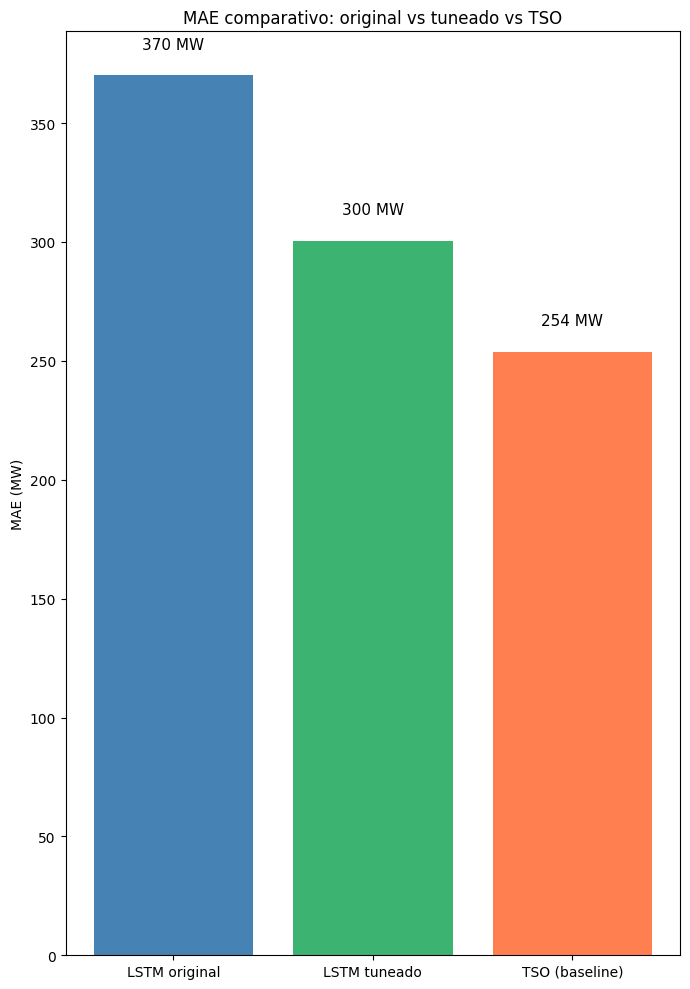

In [35]:
fig, ax = plt.subplots(figsize=(7, 10))
modelos = ['LSTM original', 'LSTM tuneado', 'TSO (baseline)']
maes = [mae, mae_tuned, mae_tso]
colors = ['steelblue', 'mediumseagreen', 'coral']
bars = ax.bar(modelos, maes, color=colors)
for bar, val in zip(bars, maes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val:.0f} MW', ha='center', va='bottom', fontsize=11)
ax.set_title('MAE comparativo: original vs tuneado vs TSO')
ax.set_ylabel('MAE (MW)')
plt.tight_layout()
plt.show()

## 9. Guardado del modelo

In [27]:
# Guardamos el modelo final y la lista de features
model.save('model/lstm_final.keras')
joblib.dump(FEATURES, 'model/features.pkl')
joblib.dump(TARGET_IDX, 'model/target_idx.pkl')
joblib.dump(WINDOW, 'model/window.pkl')

print('Modelo y artefactos guardados en /model:')
print('  - lstm_final.keras')
print('  - scaler.pkl')
print('  - features.pkl')
print('  - target_idx.pkl')
print('  - window.pkl')

Modelo y artefactos guardados en /model:
  - lstm_final.keras
  - scaler.pkl
  - features.pkl
  - target_idx.pkl
  - window.pkl
